In [2]:
import mne
from mne.datasets import eegbci

subject = 1
runs = [6]

raw_fnames = eegbci.load_data(subject, runs)
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)

raw

Extracting EDF parameters from C:\Users\10283\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [3]:
print(raw)
print(raw.info["sfreq"])
print(len(raw.ch_names))
print(raw.ch_names[:10])
raw.info.keys()

<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
160.0
64
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']


dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])

Using matplotlib as 2D backend.


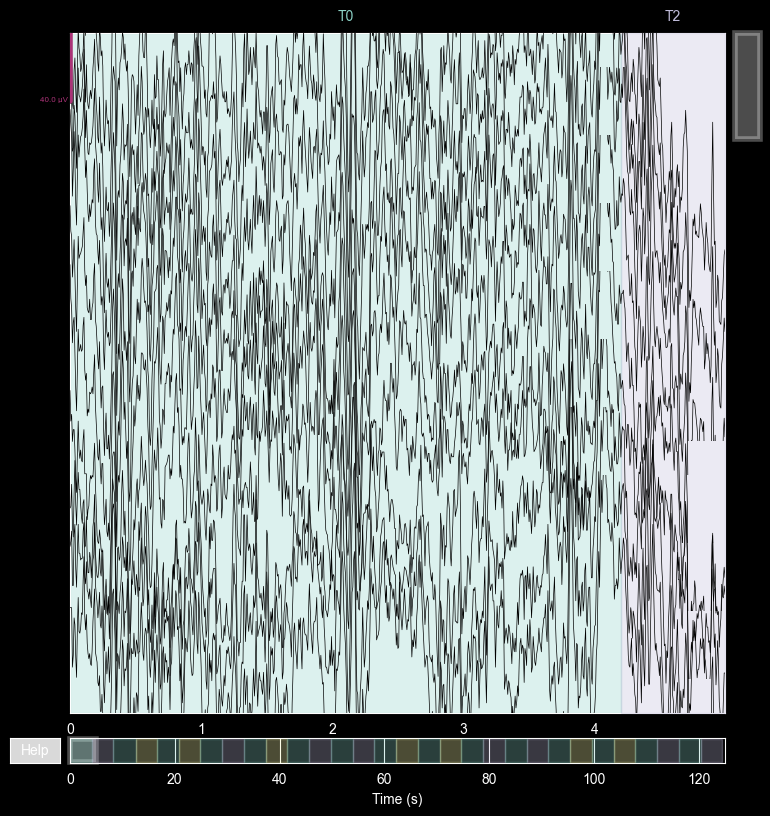

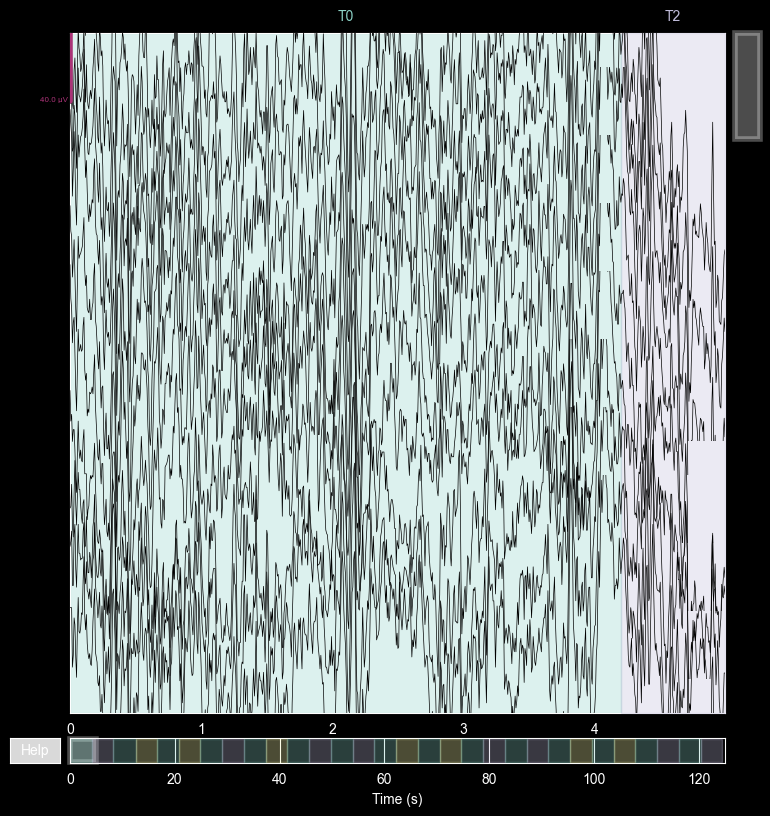

In [4]:
raw.plot(n_channels=10, duration=5)

In [5]:
events, event_id = mne.events_from_annotations(raw)

print(events[:10])
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    2]]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [6]:
picks = mne.pick_types(raw.info, eeg=True, exclude="bads")

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-1.0,
    tmax=4.0,
    picks=picks,
    baseline=None,
    preload=True
)

epochs

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 801 original time points ...
1 bad epochs dropped


<Epochs | 29 events (all good), -1 – 4 s (baseline off), ~11.4 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>

In [9]:
print(event_id)
print(epochs)
print(epochs.get_data().shape)
epochs[event_id.keys().__iter__().__next__()]

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
<Epochs | 29 events (all good), -1 – 4 s (baseline off), ~11.4 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>
(29, 64, 801)


<Epochs | 14 events (all good), -1 – 4 s (baseline off), ~5.5 MiB, data loaded,
 np.str_('T0'): 14>